# 拓展 · DCGAN（转置卷积 + 标签平滑）

> 这是 `综合题-GAN生成手写数字` 的进阶：把 MLP 换成**转置卷积（ConvTranspose2d）**，并用**标签平滑**稳定训练。
> 前置：完成 vanilla GAN 综合题（理解 G/D、交替训练、detach）。
> 按 TODO 填空（共 3 处），做完对照 `solutions/拓展-DCGAN-答案.md`。

## 三个新东西

1. **ConvTranspose2d（转置卷积）**：普通卷积缩小图，转置卷积**放大图**——CNN 生成器靠它把噪声上采样成图片
2. **BatchNorm**：稳定深层网络训练
3. **标签平滑**：把硬标签 1.0/0.0 换成软标签 0.9/0.0，防止 D 过度自信、减少模式坍塌

In [1]:
%matplotlib inline
import torch
from torch import nn
import torchvision
from torch.utils import data
from torchvision import transforms
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
z_dim = 100

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
mnist = torchvision.datasets.MNIST(root='../data', train=True, transform=transform, download=True)
data_iter = data.DataLoader(mnist, batch_size=128, shuffle=True)
print('设备:', device, '| MNIST 批数:', len(data_iter))

设备: cuda | MNIST 批数: 469


## 转置卷积尺寸公式（先记住）

```
输出尺寸 = (输入-1)×stride - 2×padding + kernel_size
```

例：输入 7×7，kernel=4，stride=2，padding=1 → (7-1)×2 − 2 + 4 = 14 ✓

所以两段 ConvTranspose2d(4, 2, 1) 能把 7×7 → 14×14 → 28×28（正好回到 MNIST 尺寸）。

## 第一步 · DCGAN 生成器（TODO 1）

用转置卷积把 100 维噪声放大成 28×28 图片：

```
z(100) → Linear(100, 7*7*128) → BatchNorm1d → ReLU
      → reshape 成 (128, 7, 7)
      → ConvTranspose2d(128→64, 4, 2, 1) → (64, 14, 14) → BatchNorm2d → ReLU
      → ConvTranspose2d(64→1, 4, 2, 1)  → (1, 28, 28) → Tanh
```

提示：`nn.Unflatten(1, (128, 7, 7))` 把 (batch, 6272) 变回 (batch, 128, 7, 7)。

In [4]:
help(nn.ConvTranspose2d)

Help on class ConvTranspose2d in module torch.nn.modules.conv:

class ConvTranspose2d(_ConvTransposeNd)
 |  ConvTranspose2d(in_channels: int, out_channels: int, kernel_size: Union[int, tuple[int, int]], stride: Union[int, tuple[int, int]] = 1, padding: Union[int, tuple[int, int]] = 0, output_padding: Union[int, tuple[int, int]] = 0, groups: int = 1, bias: bool = True, dilation: Union[int, tuple[int, int]] = 1, padding_mode: Literal['zeros', 'reflect', 'replicate', 'circular'] = 'zeros', device=None, dtype=None) -> None
 |  
 |  Applies a 2D transposed convolution operator over an input image
 |  composed of several input planes.
 |  
 |  This module can be seen as the gradient of Conv2d with respect to its input.
 |  It is also known as a fractionally-strided convolution or
 |  a deconvolution (although it is not an actual deconvolution operation as it does
 |  not compute a true inverse of convolution). For more information, see the visualizations
 |  `here`_ and the `Deconvolutional 

In [6]:
def make_generator_dcgan():
    # TODO 1: 用 Linear + Unflatten + 两个 ConvTranspose2d 组装生成器
    #         最后一层 Tanh（输出 [-1,1]，匹配归一化后的图片）
    return nn.Sequential(nn.Linear(100, 7 * 7 * 128),    #n * (7 * 7 * 128)
                         nn.BatchNorm1d(7 * 7 * 128),    
                         nn.ReLU(),
                         nn.Unflatten(1, (128, 7, 7)), #第一个arg表示把第几维参数展开成指定形状 n * 128 * 7 * 7
                         nn.ConvTranspose2d(128, 64, 4, 2, 1),    #n * 64 * 14 * 14
                         nn.BatchNorm2d(64),
                         nn.ReLU(),
                         nn.ConvTranspose2d(64, 1, 4, 2, 1),      #n * 1 * 28 * 28
                         nn.Tanh())
# ---- 自测：完成 TODO 1 后运行 ----
try:
    G = make_generator_dcgan()
    z = torch.randn(2, z_dim)
    out = G(z)
    assert out.shape == (2, 1, 28, 28), f'形状 {out.shape} 不对，期望 (2,1,28,28)'
    print('✓ DCGAN 生成器输出形状正确:', list(out.shape))
except NotImplementedError as e:
    print(f'⚠ {e}')

✓ DCGAN 生成器输出形状正确: [2, 1, 28, 28]


## 第二步 · DCGAN 判别器（TODO 2）

用普通卷积把 28×28 图片压缩到 1 个概率：

```
Conv2d(1→64, 4, 2, 1) → (64, 14, 14) → LeakyReLU
Conv2d(64→128, 4, 2, 1) → (128, 7, 7) → BatchNorm2d → LeakyReLU
Flatten → Linear(7*7*128, 1) → Sigmoid
```

（普通卷积尺寸公式：(n−k+2p)/s+1，28→14→7 正好和生成器对称。）

In [8]:
def make_discriminator_dcgan():
    # TODO 2: 用两个 Conv2d + Flatten + Linear 组装判别器
    #         最后一层 Sigmoid（输出 (0,1) 概率）
    return nn.Sequential(nn.Conv2d(1, 64, 4, 2, 1),
                         nn.LeakyReLU(0.2),
                         nn.Conv2d(64, 128, 4, 2, 1),
                         nn.BatchNorm2d(128),
                         nn.LeakyReLU(0.2),
                         nn.Flatten(),
                         nn.Linear(7 * 7 * 128, 1),
                         nn.Sigmoid())


# ---- 自测：完成 TODO 2 后运行 ----
try:
    D = make_discriminator_dcgan()
    img = torch.randn(2, 1, 28, 28)
    out = D(img)
    assert out.shape == (2, 1), f'形状 {out.shape} 不对，期望 (2,1)'
    print('✓ DCGAN 判别器输出形状正确:', list(out.shape))
except NotImplementedError as e:
    print(f'⚠ {e}')

✓ DCGAN 判别器输出形状正确: [2, 1]


## 第三步 · 训练循环 + 标签平滑（TODO 3）

训练循环和 vanilla GAN 一样（交替训 D/G、detach），唯一新增的是**标签平滑**：

- 真样本标签从 1.0 改成 **0.9**（单边平滑，D 别太自信）
- 假样本标签保持 0.0

In [12]:
def train_gan(G, D, data_iter, num_epochs=50, lr=0.0002):
    G.to(device); D.to(device)
    loss = nn.BCELoss()
    opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

    for epoch in range(num_epochs):
        for X, _ in data_iter:
            X = X.to(device)
            batch = X.size(0)
            # TODO 3: 标签平滑——真标签用 0.9（不是 1.0），假标签用 0.0
            real_label = torch.full((batch, 1), 0.85, device=device)   # 平滑后
            fake_label = torch.zeros(batch, 1, device=device)

            # ---- ① 训 D ----
            z = torch.randn(batch, z_dim, device=device)
            fake = G(z)
            loss_D = loss(D(X), real_label) + loss(D(fake.detach()), fake_label)
            opt_D.zero_grad(); loss_D.backward(); opt_D.step()

            # ---- ② 训 G ----
            z = torch.randn(batch, z_dim, device=device)
            fake = G(z)
            loss_G = loss(D(fake), real_label)   # 想让 D 把假判成 0.9
            opt_G.zero_grad(); loss_G.backward(); opt_G.step()

        if (epoch + 1) % 10 == 0:
            print(f'epoch {epoch+1}, loss_D {loss_D.item():.4f}, loss_G {loss_G.item():.4f}')
    return G, D

## 第四步 · 训练 + 可视化

（TODO 1~3 全完成后运行，50 个 epoch 需要几分钟）

epoch 10, loss_D 0.6312, loss_G 2.4240
epoch 20, loss_D 0.5605, loss_G 2.8098
epoch 30, loss_D 0.5821, loss_G 2.4735
epoch 40, loss_D 0.5667, loss_G 2.9527
epoch 50, loss_D 0.5907, loss_G 2.4295
epoch 60, loss_D 0.5740, loss_G 2.3172
epoch 70, loss_D 0.6509, loss_G 2.2958
epoch 80, loss_D 0.5605, loss_G 3.2512
epoch 90, loss_D 0.6044, loss_G 3.0497
epoch 100, loss_D 0.6822, loss_G 2.3531


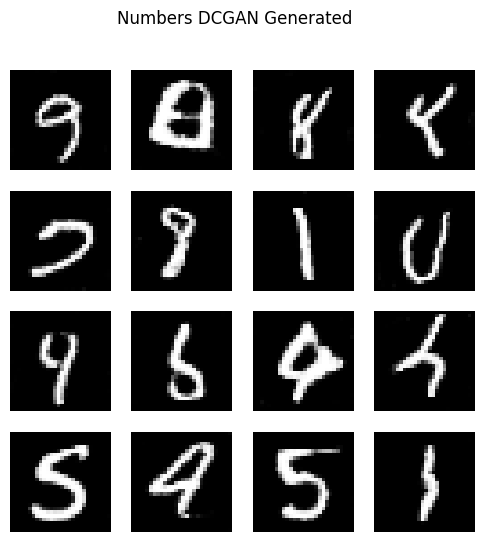

In [13]:
try:
    G = make_generator_dcgan()
    D = make_discriminator_dcgan()
    train_gan(G, D, data_iter, num_epochs=100)
except NotImplementedError as e:
    print(f'⚠ {e}，先完成所有 TODO')
else:
    G.eval()
    with torch.no_grad():
        z = torch.randn(16, z_dim, device=device)
        fake = G(z).cpu().view(16, 28, 28)
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake[i], cmap='gray')
        ax.axis('off')
    plt.suptitle('Numbers DCGAN Generated')
    plt.show()

## 拓展收获（做完后能回答）

1. `ConvTranspose2d` 和 `Conv2d` 是什么关系？为什么生成器用它？
2. 标签平滑为什么能让 GAN 更稳？
3. 对比 vanilla GAN（MLP）和 DCGAN（转置卷积）的生成质量，有什么差别？

做完对照 `solutions/拓展-DCGAN-答案.md`。